In [2]:
# Retail & Marketing Analytics Project
# Part 2: Data Cleaning and Preprocessing

"""
Project: Retail & Marketing Analytics - Customer Segmentation & Sales Optimization
Part: 02 - Data Cleaning and Preprocessing
Date: 06-15-2026

Objective:
- Handle missing values
- Remove duplicates
- Convert data types
- Detect and treat outliers
- Feature engineering
- Save cleaned dataset
"""

# ============================================================================
# 1. IMPORT LIBRARIES AND LOAD DATA
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from datetime import datetime
import warnings

warnings.filterwarnings('ignore')

# Load the raw data
df_sales = pd.read_csv('data/raw/retail_sales_data.csv')

print("="*80)
print("DATA CLEANING AND PREPROCESSING")
print("="*80)
print(f"\nInitial Dataset Shape: {df_sales.shape}")
print(f"Initial Memory Usage: {df_sales.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Create a copy for cleaning
df_clean = df_sales.copy()

DATA CLEANING AND PREPROCESSING

Initial Dataset Shape: (30000, 9)
Initial Memory Usage: 8.57 MB


In [3]:
# ============================================================================
# 2. HANDLE MISSING VALUES
# ============================================================================

print("\n" + "="*80)
print("STEP 1: HANDLING MISSING VALUES")
print("="*80)

# Check missing values
print("\n Missing Values Before Treatment:")
missing_before = df_clean.isnull().sum()
missing_before_pct = (missing_before / len(df_clean) * 100).round(2)
missing_df = pd.DataFrame({
    'Column': missing_before.index,
    'Missing_Count': missing_before.values,
    'Missing_Percentage': missing_before_pct.values
})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)
print(missing_df)

# Strategy for handling missing values
print("\n Treatment Strategy:")

# Separate columns by type
numerical_cols = df_clean.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_cols = df_clean.select_dtypes(include=['object']).columns.tolist()

# Handle numerical missing values - Fill with median
for col in numerical_cols:
    if df_clean[col].isnull().sum() > 0:
        median_value = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(median_value)
        print(f"  ✓ {col}: Filled with median ({median_value:.2f})")

# Handle categorical missing values - Fill with mode or 'Unknown'
for col in categorical_cols:
    if df_clean[col].isnull().sum() > 0:
        if df_clean[col].mode().empty:
            df_clean[col] = df_clean[col].fillna('Unknown')
            print(f"  ✓ {col}: Filled with 'Unknown'")
        else:
            mode_value = df_clean[col].mode()[0]
            df_clean[col] = df_clean[col].fillna(mode_value)
            print(f"  ✓ {col}: Filled with mode ('{mode_value}')")

# Verify no missing values remain
print(f"\n Missing values after treatment: {df_clean.isnull().sum().sum()}")


STEP 1: HANDLING MISSING VALUES

 Missing Values Before Treatment:
         Column  Missing_Count  Missing_Percentage
2      SUPPLIER             33                0.11
6  RETAIL SALES              1                0.00

 Treatment Strategy:
  ✓ RETAIL SALES: Filled with median (0.16)
  ✓ SUPPLIER: Filled with mode ('THE COUNTRY VINTNER, LLC DBA WINEBOW')

 Missing values after treatment: 0


In [4]:
# ============================================================================
# 3. REMOVE DUPLICATES
# ============================================================================

print("\n" + "="*80)
print("STEP 2: REMOVING DUPLICATES")
print("="*80)

# Check duplicates
duplicates_before = df_clean.duplicated().sum()
print(f"\n Duplicate rows found: {duplicates_before}")

# Remove duplicates
df_clean = df_clean.drop_duplicates()
print(f"✓ Duplicates removed: {duplicates_before}")
print(f"✓ New dataset shape: {df_clean.shape}")

# Reset index after removing duplicates
df_clean.reset_index(drop=True, inplace=True)


STEP 2: REMOVING DUPLICATES

 Duplicate rows found: 0
✓ Duplicates removed: 0
✓ New dataset shape: (30000, 9)


In [5]:
# ============================================================================
# 4. DATA TYPE CONVERSION
# ============================================================================

print("\n" + "="*80)
print("STEP 3: DATA TYPE CONVERSION")
print("="*80)

# Drop rows where ITEM CODE is 'BC' or 'WC'
df_clean = df_clean[~df_clean['ITEM CODE'].isin(['BC', 'WC'])].copy()

if 'YEAR' in df_clean.columns and 'MONTH' in df_clean.columns:
    print("\n Creating Clean Monthly Period Timeline:")
    
    # 1. Feed the columns directly to Pandas with a temporary day=1
    df_clean['MONTH-PERIOD'] = pd.to_datetime(
        df_clean[['YEAR', 'MONTH']].assign(day=1)
    ).dt.to_period('M')
    
    print("   ✓ Successfully created 'MONTH-PERIOD' (Format: YYYY-MM)")
    
    # 2. Fix your original numerical columns back to clean integers
    df_clean['YEAR'] = df_clean['YEAR'].astype('int32')
    df_clean['MONTH'] = df_clean['MONTH'].astype('int32')

# Convert categorical columns to category type for memory optimization
categorical_columns = ['Supplier', 'ITEM DESCRIPTION', 'ITEM TYPE']
for col in categorical_columns:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].astype('category')
        print(f"✓ Converted {col} to category")

# Ensure numerical columns are correct type
if 'ITEM CODE' in df_clean.columns:
    df_clean['ITEM CODE'] = df_clean['ITEM CODE'].astype('int32')
    
print(f"\n Data types optimized!")
print(f"Memory usage after optimization: {df_clean.memory_usage(deep=True).sum() / 1024**2:.2f} MB")


STEP 3: DATA TYPE CONVERSION

 Creating Clean Monthly Period Timeline:
   ✓ Successfully created 'MONTH-PERIOD' (Format: YYYY-MM)
✓ Converted ITEM DESCRIPTION to category
✓ Converted ITEM TYPE to category

 Data types optimized!
Memory usage after optimization: 4.83 MB



STEP 4: OUTLIER DETECTION AND TREATMENT

 Outlier Analysis:

RETAIL SALES:
  - Outliers detected: 5019 (16.73%)
  - Lower bound: -4.38
  - Upper bound: 7.31

RETAIL TRANSFERS:
  - Outliers detected: 5070 (16.90%)
  - Lower bound: -4.50
  - Upper bound: 7.50

WAREHOUSE SALES:
  - Outliers detected: 3831 (12.77%)
  - Lower bound: -9.00
  - Upper bound: 15.00

✓ Saved: 03_outliers_before_treatment.png


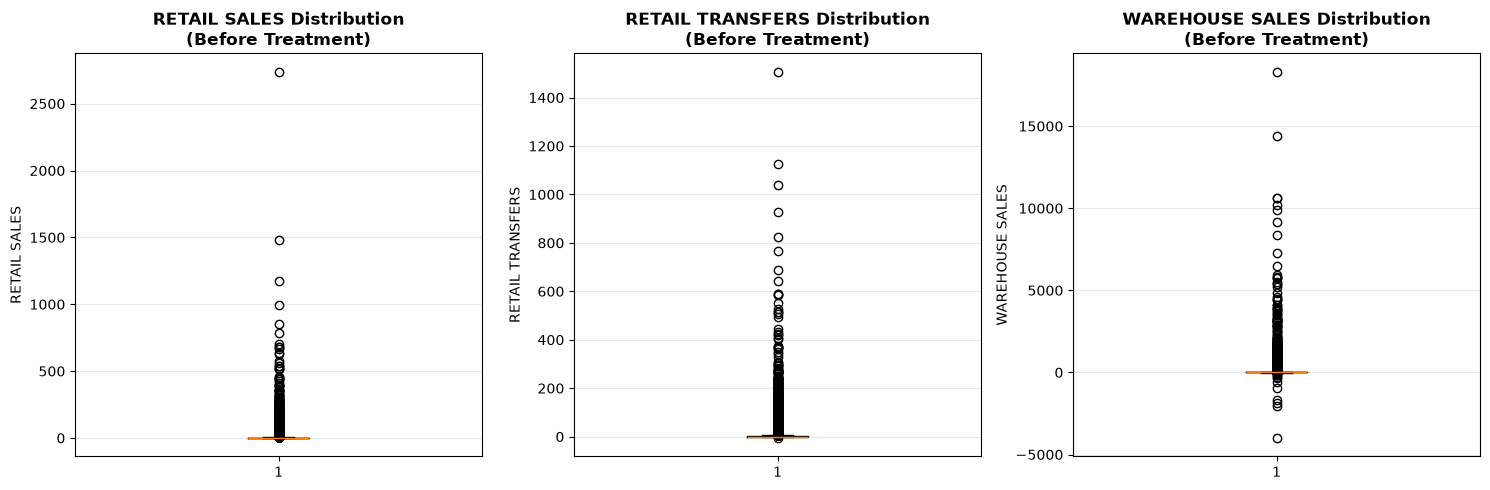


 Outlier Treatment (Capping):
   ✓ RETAIL SALES: Outliers capped to [0.00, 7.31]
   ✓ RETAIL TRANSFERS: Outliers capped to [0.00, 7.50]
   ✓ WAREHOUSE SALES: Outliers capped to [0.00, 15.00]
✓ Saved: 04_outliers_after_treatment.png


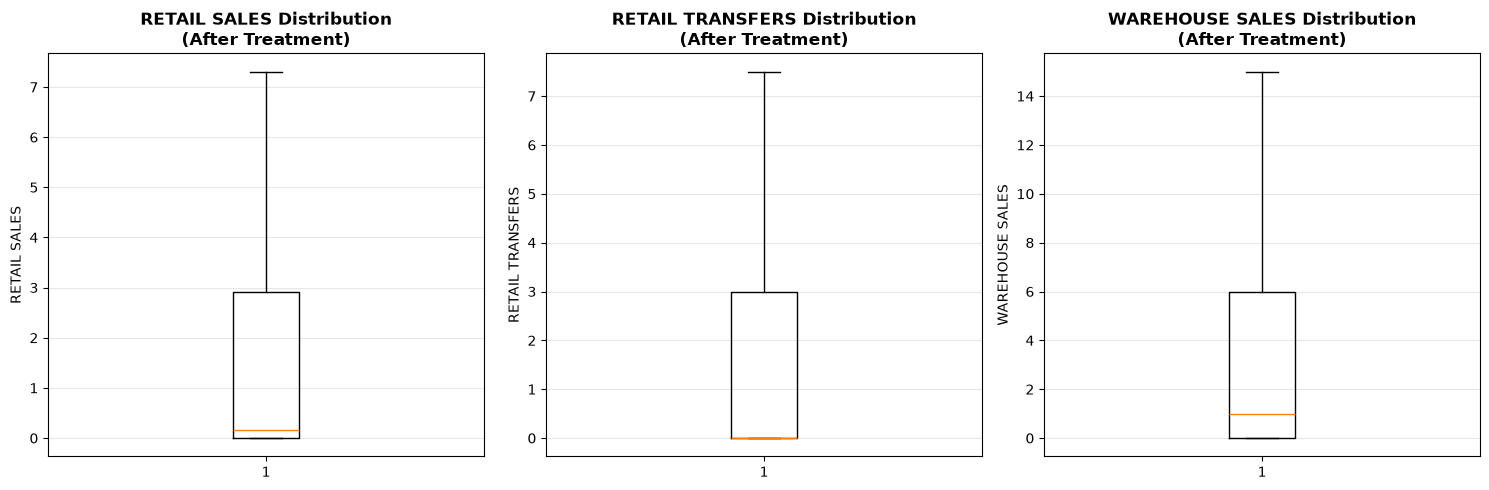

In [6]:
# ============================================================================
# 5. OUTLIER DETECTION AND TREATMENT
# ============================================================================

print("\n" + "="*80)
print("STEP 4: OUTLIER DETECTION AND TREATMENT")
print("="*80)

def detect_outliers_iqr(data, column):
    """Detect outliers using IQR method"""
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Use your actual dataset columns
outlier_columns = ['RETAIL SALES', 'RETAIL TRANSFERS', 'WAREHOUSE SALES']

print("\n Outlier Analysis:")
outlier_summary = []

for col in outlier_columns:
    if col in df_clean.columns:
        outliers, lb, ub = detect_outliers_iqr(df_clean, col)
        outlier_pct = (len(outliers) / len(df_clean) * 100)
        outlier_summary.append({
            'Column': col,
            'Outliers': len(outliers),
            'Percentage': f"{outlier_pct:.2f}%",
            'Lower_Bound': f"{lb:.2f}",
            'Upper_Bound': f"{ub:.2f}"
        })
        print(f"\n{col}:")
        print(f"  - Outliers detected: {len(outliers)} ({outlier_pct:.2f}%)")
        print(f"  - Lower bound: {lb:.2f}")
        print(f"  - Upper bound: {ub:.2f}")

# Visualize outliers before treatment
fig, axes = plt.subplots(1, len(outlier_columns), figsize=(15, 5))
if len(outlier_columns) == 1:
    axes = [axes]

for idx, col in enumerate(outlier_columns):
    if col in df_clean.columns:
        axes[idx].boxplot(df_clean[col].dropna())
        axes[idx].set_title(f'{col} Distribution\n(Before Treatment)', fontweight='bold')
        axes[idx].set_ylabel(col)
        axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/figures/03_outliers_before_treatment.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: 03_outliers_before_treatment.png")
plt.show()

# Treatment: Cap outliers (Winsorization) using explicit assignment (no inplace bugs)
print("\n Outlier Treatment (Capping):")
for col in outlier_columns:
    if col in df_clean.columns:
        outliers, lb, ub = detect_outliers_iqr(df_clean, col)
        if len(outliers) > 0:
            # Keep original for reference
            df_clean[f'{col}_Original'] = df_clean[col]

            safe_lb = max(0,lb)  # Ensure lower bound is not negative if it doesn't make sense for the data
            # Cap values using safe assignment
            df_clean[col] = df_clean[col].clip(lower=safe_lb, upper=ub)
            print(f"   ✓ {col}: Outliers capped to [{safe_lb:.2f}, {ub:.2f}]")
            

# Visualize after treatment
fig, axes = plt.subplots(1, len(outlier_columns), figsize=(15, 5))
if len(outlier_columns) == 1:
    axes = [axes]

for idx, col in enumerate(outlier_columns):
    if col in df_clean.columns:
        axes[idx].boxplot(df_clean[col].dropna())
        axes[idx].set_title(f'{col} Distribution\n(After Treatment)', fontweight='bold')
        axes[idx].set_ylabel(col)
        axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/figures/04_outliers_after_treatment.png', dpi=300, bbox_inches='tight')
print("✓ Saved: 04_outliers_after_treatment.png")
plt.show()

In [7]:
# ============================================================================
# 6. FEATURE ENGINEERING
# ============================================================================

import numpy as np
import pandas as pd

print("\n" + "="*80)
print("STEP 5: FEATURE ENGINEERING")
print("="*80)

# 1. Time-based features (Adapted for your MONTH-PERIOD object)
if 'MONTH-PERIOD' in df_clean.columns:
    print("\n Creating Time-Based Features:")
    # Pull the month integer out of the Period object
    df_clean['Month_Int'] = df_clean['MONTH-PERIOD'].dt.month
    df_clean['Quarter'] = df_clean['MONTH-PERIOD'].dt.quarter
    print("   ✓ Month Integer, Quarter derived from MONTH-PERIOD")

# 2. Revenue and Volume metrics (Total Operational Flow)
if 'RETAIL SALES' in df_clean.columns and 'WAREHOUSE SALES' in df_clean.columns:
    print("\n Creating Volume and Flow Metrics:")
    # Combine the main sales channels to get absolute supply flow
    df_clean['TOTAL_SALES_VOLUME'] = df_clean['RETAIL SALES'] + df_clean['WAREHOUSE SALES']
    
    # Calculate channel contribution percentages safely (avoiding divide-by-zero)
    df_clean['RETAIL_CHANNEL_PCT'] = np.where(df_clean['TOTAL_SALES_VOLUME'] > 0, 
                                               (df_clean['RETAIL SALES'] / df_clean['TOTAL_SALES_VOLUME']) * 100, 0)
    df_clean['WAREHOUSE_CHANNEL_PCT'] = np.where(df_clean['TOTAL_SALES_VOLUME'] > 0, 
                                                  (df_clean['WAREHOUSE SALES'] / df_clean['TOTAL_SALES_VOLUME']) * 100, 0)
    
    # Transfer-to-Sales Friction Ratio (High values mean logistical restocking strain)
    if 'RETAIL TRANSFERS' in df_clean.columns:
        df_clean['TRANSFER_TO_SALES_RATIO'] = np.where(df_clean['RETAIL SALES'] > 0,
                                                       df_clean['RETAIL TRANSFERS'] / df_clean['RETAIL SALES'], 0)
        print("   ✓ Total Sales Volume, Channel % Breakdown, Logistical Transfer Ratios")

# 3. Product performance metrics (Aggregated on ITEM CODE)
if 'ITEM CODE' in df_clean.columns and 'TOTAL_SALES_VOLUME' in df_clean.columns:
    print("\n Creating Product Performance Metrics:")
    product_performance = df_clean.groupby('ITEM CODE')['TOTAL_SALES_VOLUME'].agg(['sum', 'mean', 'count'])
    product_performance.columns = ['ITEM_TOTAL_VOLUME', 'ITEM_AVG_VOLUME', 'ITEM_RECORD_COUNT']
    
    df_clean = df_clean.merge(product_performance, left_on='ITEM CODE', right_index=True, how='left')
    print("   ✓ Item Total Volume, Item Average Volume, Item Lifecycle Appearance Counts")

# 4. Supplier performance metrics (Aggregated on SUPPLIER dominance)
if 'SUPPLIER' in df_clean.columns and 'TOTAL_SALES_VOLUME' in df_clean.columns:
    print("\n Creating Supplier Dominance Metrics:")
    supplier_performance = df_clean.groupby('SUPPLIER')['TOTAL_SALES_VOLUME'].agg(['sum', 'mean', 'nunique'])
    supplier_performance.columns = ['SUPPLIER_TOTAL_VOLUME', 'SUPPLIER_AVG_VOLUME', 'SUPPLIER_UNIQUE_ITEMS']
    
    df_clean = df_clean.merge(supplier_performance, left_on='SUPPLIER', right_index=True, how='left')
    print("   ✓ Supplier Total Volume, Supplier Average Volume, Supplier Portfolio Catalog Size")

# 5. Operational scale categories (Quartile-based groupings on combined volume)
if 'TOTAL_SALES_VOLUME' in df_clean.columns:
    print("\n Creating Sales Velocity Categories:")
    df_clean['VOLUME_CATEGORY'] = pd.qcut(df_clean['TOTAL_SALES_VOLUME'], 
                                           q=4, 
                                           labels=['Low Volume', 'Medium Volume', 'High Volume', 'Top Tier Volume'],
                                           duplicates='drop')
    print("   ✓ Volume Category (Quartile-based velocity classification)")

# 6. Season classification (Using Month_Int created in step 1)
if 'Month_Int' in df_clean.columns:
    print("\n Creating Seasonal Features:")
    season_map = {
        12: 'Winter', 1: 'Winter', 2: 'Winter',
        3: 'Spring', 4: 'Spring', 5: 'Spring',
        6: 'Summer', 7: 'Summer', 8: 'Summer',
        9: 'Fall', 10: 'Fall', 11: 'Fall'
    }
    df_clean['SEASON'] = df_clean['Month_Int'].map(season_map)
    print("   ✓ Operational Season Classification")

print(f"\n Feature Engineering Completed!")
print(f"New dataset shape: {df_clean.shape[0]:,} rows x {df_clean.shape[1]} columns")


STEP 5: FEATURE ENGINEERING

 Creating Time-Based Features:
   ✓ Month Integer, Quarter derived from MONTH-PERIOD

 Creating Volume and Flow Metrics:
   ✓ Total Sales Volume, Channel % Breakdown, Logistical Transfer Ratios

 Creating Product Performance Metrics:
   ✓ Item Total Volume, Item Average Volume, Item Lifecycle Appearance Counts

 Creating Supplier Dominance Metrics:
   ✓ Supplier Total Volume, Supplier Average Volume, Supplier Portfolio Catalog Size

 Creating Sales Velocity Categories:
   ✓ Volume Category (Quartile-based velocity classification)

 Creating Seasonal Features:
   ✓ Operational Season Classification

 Feature Engineering Completed!
New dataset shape: 29,996 rows x 27 columns


In [8]:
# ============================================================================
# 7. DATA VALIDATION
# ============================================================================

print("\n" + "="*80)
print("STEP 6: DATA VALIDATION")
print("="*80)

# Check for negative values in key supply chain columns
print("\n Checking for Invalid Values:")

validation_checks = []

if 'RETAIL SALES' in df_clean.columns:
    negative_retail = (df_clean['RETAIL SALES'] < 0).sum()
    validation_checks.append(f"Negative Retail Sales: {negative_retail}")
    
if 'WAREHOUSE SALES' in df_clean.columns:
    negative_wh = (df_clean['WAREHOUSE SALES'] < 0).sum()
    validation_checks.append(f"Negative Warehouse Sales: {negative_wh}")
    
if 'RETAIL TRANSFERS' in df_clean.columns:
    # Transfers can sometimes be negative in retail for returns, but good to check
    negative_transfers = (df_clean['RETAIL TRANSFERS'] < 0).sum()
    validation_checks.append(f"Negative Retail Transfers: {negative_transfers}")

for check in validation_checks:
    print(f"  • {check}")

print("\n Validation Complete!")

# ============================================================================
# 8. SUMMARY STATISTICS AFTER CLEANING
# ============================================================================

print("\n" + "="*80)
print("CLEANED DATA SUMMARY")
print("="*80)

print(f"\n Final Dataset Shape: {df_clean.shape}")
print(f" Records removed: {df_sales.shape[0] - df_clean.shape[0]}")
print(f" Features added: {df_clean.shape[1] - df_sales.shape[1]}")
print(f" Memory usage: {df_clean.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\n Data Quality Metrics:")
print(f"  • Missing values: {df_clean.isnull().sum().sum()}")
print(f"  • Duplicate rows: {df_clean.duplicated().sum()}")
print(f"  • Complete rows: {df_clean.dropna().shape[0]:,} ({(df_clean.dropna().shape[0]/len(df_clean)*100):.2f}%)")

print("\n Key Statistics:")
if 'TOTAL_SALES_VOLUME' in df_clean.columns:
    print(f"  • Total Combined Volume: {df_clean['TOTAL_SALES_VOLUME'].sum():,.2f}")
    print(f"  • Average Volume per Row: {df_clean['TOTAL_SALES_VOLUME'].mean():,.2f}")
if 'SUPPLIER' in df_clean.columns:
    print(f"  • Unique Suppliers: {df_clean['SUPPLIER'].nunique():,}")
if 'ITEM CODE' in df_clean.columns:
    print(f"  • Unique Items: {df_clean['ITEM CODE'].nunique():,}")

# ============================================================================
# 9. SAVE CLEANED DATA
# ============================================================================

print("\n" + "="*80)
print("STEP 7: SAVING CLEANED DATA")
print("="*80)

# Save cleaned dataset
output_path = 'data/processed/cleaned_retail_sales.csv'
df_clean.to_csv(output_path, index=False)
print(f"✓ Cleaned data saved: {output_path}")

# Save data dictionary
data_dict = pd.DataFrame({
    'Column_Name': df_clean.columns,
    'Data_Type': df_clean.dtypes.values,
    'Non_Null_Count': df_clean.count().values,
    'Null_Count': df_clean.isnull().sum().values,
    'Unique_Values': [df_clean[col].nunique() for col in df_clean.columns],
    'Sample_Value': [df_clean[col].iloc[0] if len(df_clean) > 0 else None for col in df_clean.columns]
})

dict_path = 'docs/data_dictionary.csv'
data_dict.to_csv(dict_path, index=False)
print(f"✓ Data dictionary saved: {dict_path}")

# Create cleaning summary report (Updated categories for your exact dataset metrics)
cleaning_report = f"""
DATA CLEANING AND PREPROCESSING REPORT
{'='*80}

1. DATA QUALITY IMPROVEMENTS
   Before Cleaning:
   - Records: {df_sales.shape[0]:,}
   - Missing Values: {df_sales.isnull().sum().sum():,}
   
   After Cleaning:
   - Records: {df_clean.shape[0]:,}
   - Missing Values: {df_clean.isnull().sum().sum()}
   - Duplicates: {df_clean.duplicated().sum()}
   
   Records Removed: {df_sales.shape[0] - df_clean.shape[0]:,}
   Data Quality Score: {((1 - df_clean.isnull().sum().sum()/(df_clean.shape[0]*df_clean.shape[1])) * 100):.2f}%

2. FEATURES ENGINEERED
   Original Features: {df_sales.shape[1]}
   New Features: {df_clean.shape[1] - df_sales.shape[1]}
   Total Features: {df_clean.shape[1]}
   
   Categories of New Features:
   - Time-based: Month_Int, Quarter (Derived cleanly from MONTH-PERIOD)
   - Volume Flow: TOTAL_SALES_VOLUME, RETAIL_CHANNEL_PCT, WAREHOUSE_CHANNEL_PCT, TRANSFER_TO_SALES_RATIO
   - Item Performance: ITEM_TOTAL_VOLUME, ITEM_AVG_VOLUME, ITEM_RECORD_COUNT
   - Supplier Dominance: SUPPLIER_TOTAL_VOLUME, SUPPLIER_AVG_VOLUME, SUPPLIER_UNIQUE_ITEMS
   - Categorical/Velocity: VOLUME_CATEGORY, SEASON

3. DATA TYPE OPTIMIZATION
   Memory Before: {df_sales.memory_usage(deep=True).sum() / 1024**2:.2f} MB
   Memory After: {df_clean.memory_usage(deep=True).sum() / 1024**2:.2f} MB
   Memory Saved: {(df_sales.memory_usage(deep=True).sum() - df_clean.memory_usage(deep=True).sum()) / 1024**2:.2f} MB

4. OUTLIER TREATMENT
   Method: IQR (Interquartile Range) with Winsorization Capping
   Columns Treated: {', '.join(outlier_columns)}

5. NEXT STEPS
   ✓ Proceed to Exploratory Data Analysis (Notebook 03)
   - Channel breakdown analysis (Retail vs. Warehouse dominance)
   - Seasonal trend variations across the 4-month snapshot
   - High-velocity product portfolio identification
   - Supplier catalog diversity assessment

Report Generated: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}
{'='*80}
"""

report_path = 'outputs/reports/02_cleaning_report.txt'
with open(report_path, 'w', encoding='utf-8') as f:
    f.write(cleaning_report)
print(f"✓ Cleaning report saved: {report_path}")

print(cleaning_report)

print("\n" + "="*80)
print("Part2 COMPLETED SUCCESSFULLY!")
print("="*80)
print("\n Next Step: Part 3 - Exploratory Data Analysis")
print("="*80)


STEP 6: DATA VALIDATION

 Checking for Invalid Values:
  • Negative Retail Sales: 0
  • Negative Warehouse Sales: 0
  • Negative Retail Transfers: 0

 Validation Complete!

CLEANED DATA SUMMARY

 Final Dataset Shape: (29996, 27)
 Records removed: 4
 Features added: 18
 Memory usage: 9.87 MB

 Data Quality Metrics:
  • Missing values: 0
  • Duplicate rows: 0
  • Complete rows: 29,996 (100.00%)

 Key Statistics:
  • Total Combined Volume: 177,079.67
  • Average Volume per Row: 5.90
  • Unique Suppliers: 290
  • Unique Items: 15,666

STEP 7: SAVING CLEANED DATA
✓ Cleaned data saved: data/processed/cleaned_retail_sales.csv
✓ Data dictionary saved: docs/data_dictionary.csv
✓ Cleaning report saved: outputs/reports/02_cleaning_report.txt

DATA CLEANING AND PREPROCESSING REPORT

1. DATA QUALITY IMPROVEMENTS
   Before Cleaning:
   - Records: 30,000
   - Missing Values: 34

   After Cleaning:
   - Records: 29,996
   - Missing Values: 0
   - Duplicates: 0

   Records Removed: 4
   Data Quality S